# Model Interpretability — Grad-CAM
We use Grad-CAM to visualize which image regions the final model focuses on when making predictions. This builds trust and reveals whether the model attends to the lesion or to irrelevant background.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

import tensorflow as tf
from tensorflow import keras

2026-03-04 20:12:22.399508: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 20:12:24.241126: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 20:12:39.673824: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
PROJECT_ROOT = Path("../").resolve()
DATA_DIR = PROJECT_ROOT / "data"
ORGANIZED_DIR = DATA_DIR / "organized"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"

IMG_SIZE = 256
CLASS_NAMES = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

## 1. Load Model

In [3]:
model_dir = MODELS_DIR / "final"

keras_path = model_dir / "best_model.keras"
h5_path = model_dir / "best_model.h5"

if keras_path.exists():
    model_path = keras_path
elif h5_path.exists():
    model_path = h5_path
else:
    raise FileNotFoundError("Best model not found (.keras or .h5)")

model = keras.models.load_model(str(model_path))

print(f"Model loaded from {model_path.name}. Layers: {len(model.layers)}")

I0000 00:00:1772655170.956829  566043 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13685 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9
2026-03-04 20:12:51.549090: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Model loaded from best_model.h5. Layers: 344


In [4]:
# Identify the last convolutional layer — this is where Grad-CAM is applied
last_conv_layer = next(
    l for l in reversed(model.layers)
    if isinstance(l, keras.layers.Conv2D)
)
print(f"Last conv layer: {last_conv_layer.name}")

Last conv layer: top_conv


## 2. Grad-CAM Implementation
Grad-CAM computes the gradient of the predicted class score with respect to the feature maps of the target conv layer, then takes a weighted average of the feature maps using those gradients as weights.

In [5]:
def compute_gradcam(model, img_array, last_conv_layer_name, pred_index=None):
    """Return the Grad-CAM heatmap for a single image."""
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(pred_index), float(tf.reduce_max(predictions))

In [24]:
def overlay_gradcam(img_rgb, heatmap, alpha=0.4):
    """Resize heatmap and overlay on original image."""
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlaid = (img_rgb * (1 - alpha) + heatmap_rgb * alpha).astype(np.uint8)
    return overlaid

## 3. Generate Grad-CAM for One Sample per Class

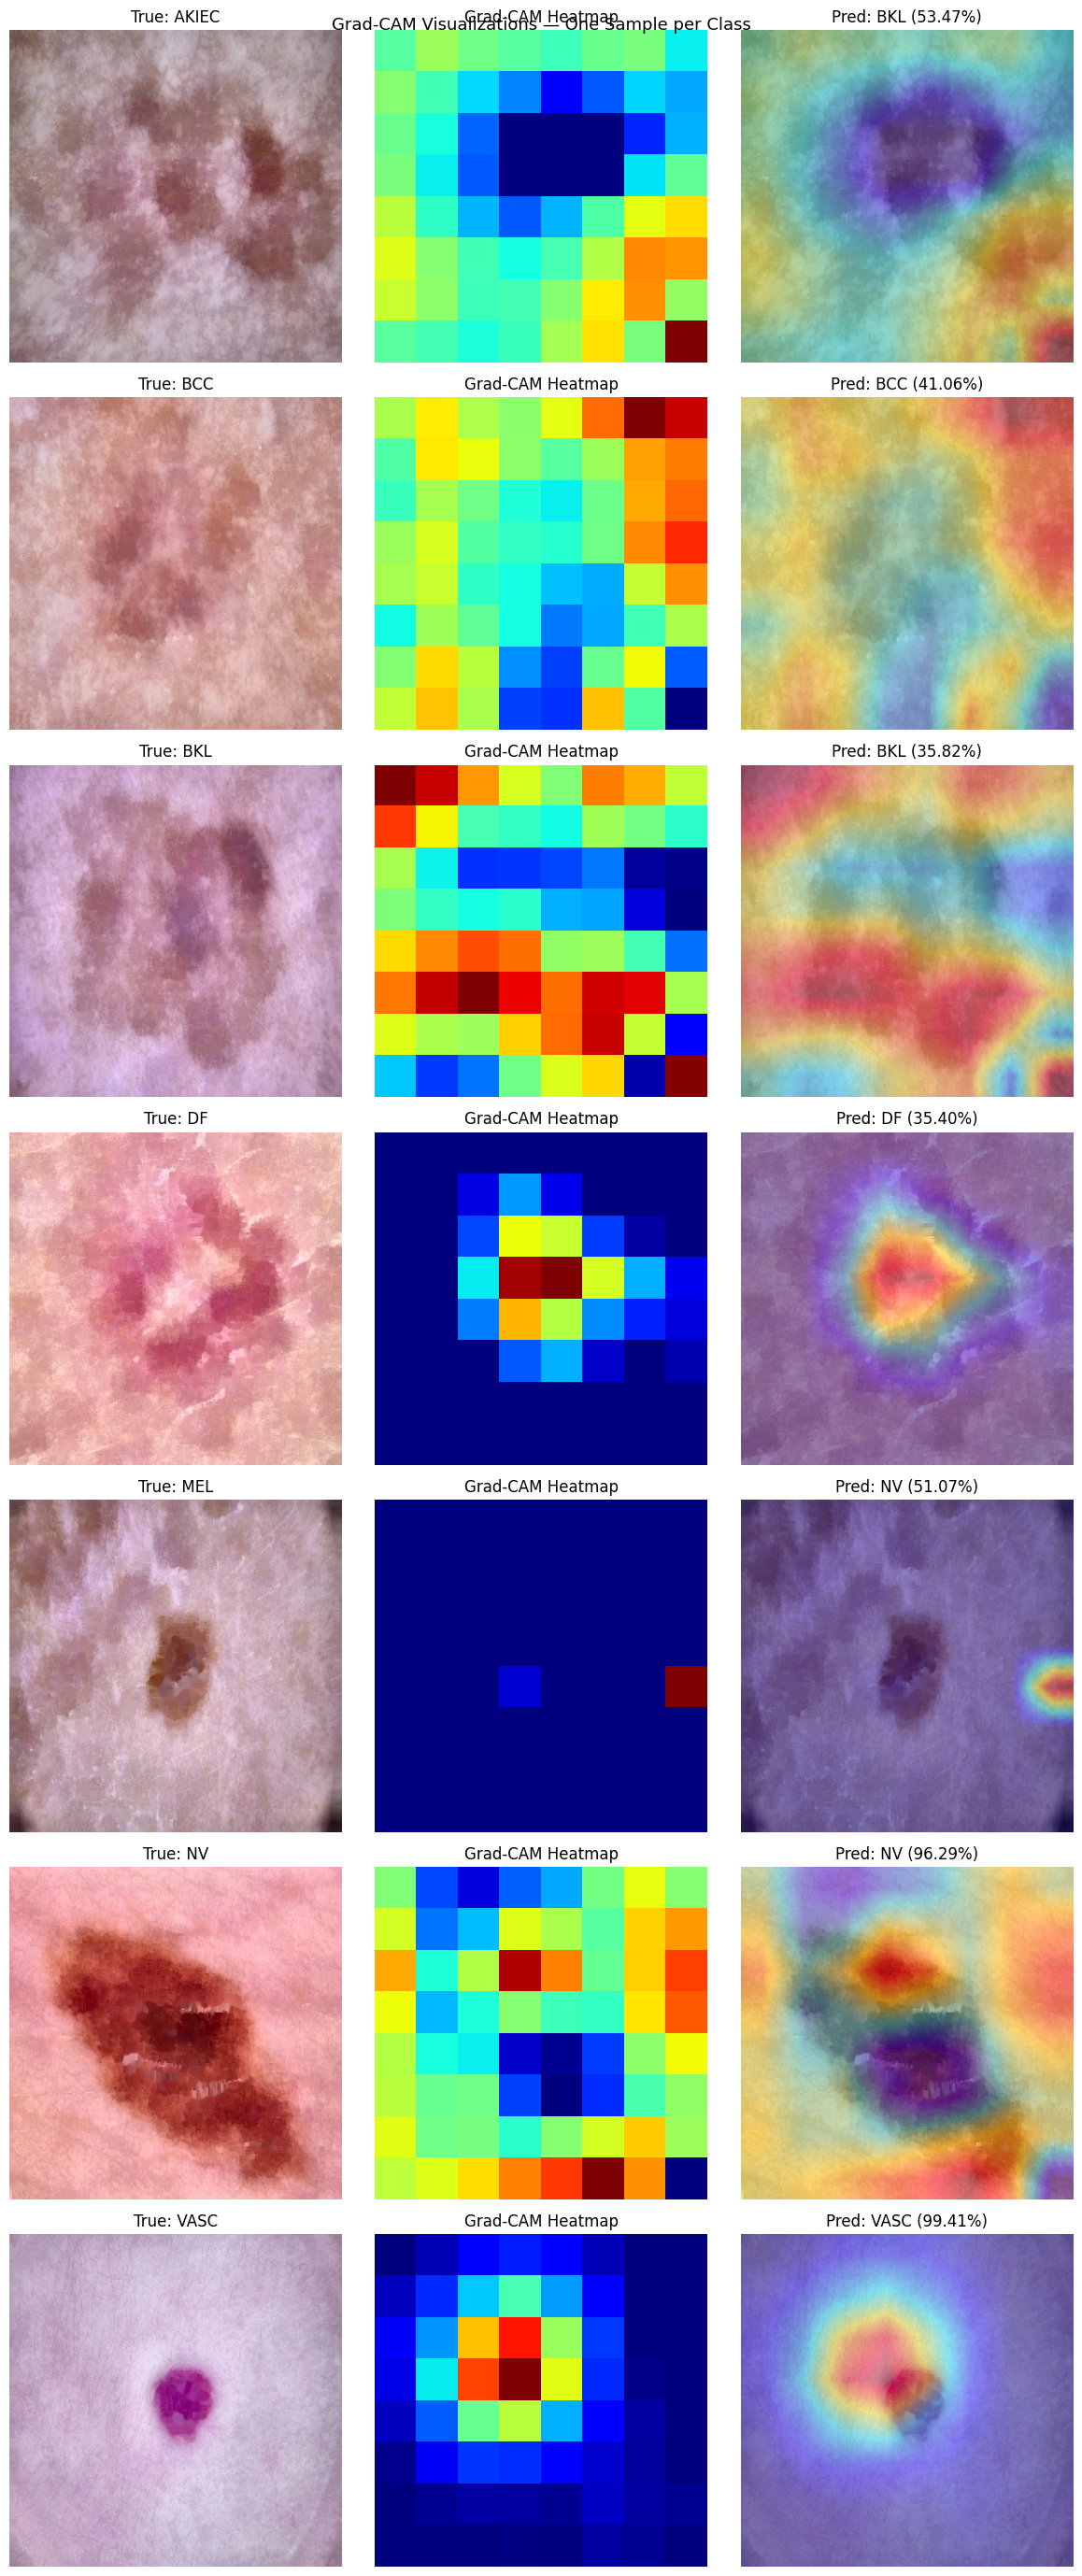

In [25]:
def load_img(path):
    img = cv2.imread(str(path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    return img_resized

fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(12, 4 * len(CLASS_NAMES)))

for row, cls_name in enumerate(CLASS_NAMES):
    cls_dir = ORGANIZED_DIR / "test" / cls_name
    sample_path = next(cls_dir.glob("*.jpg"), None)
    if sample_path is None:
        continue

    img_rgb = load_img(sample_path)
    img_arr = tf.cast(img_rgb, tf.float32)[tf.newaxis, ...]

    heatmap, pred_idx, confidence = compute_gradcam(
        model, img_arr, last_conv_layer.name
    )
    heatmap = heatmap.astype("float32")
    overlaid = overlay_gradcam(img_rgb, heatmap)

    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f"True: {cls_name}")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title("Grad-CAM Heatmap")
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlaid)
    axes[row, 2].set_title(f"Pred: {CLASS_NAMES[pred_idx]} ({confidence:.2%})")
    axes[row, 2].axis('off')

plt.suptitle("Grad-CAM Visualizations — One Sample per Class", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "gradcam_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Observations
If heatmap activations concentrate on the lesion center, the model is using the correct discriminative region. Activations spread across background skin or image borders suggest the model is using spurious correlations and may benefit from stronger segmentation preprocessing.

In [27]:
print("Grad-CAM analysis complete.")
# print(f"Visualization saved to: {RESULTS_DIR / 'gradcam_per_class.png'}")

Grad-CAM analysis complete.
